•	Loads the image
•	Resizes it to a standard size so the processing is consistent.
•	Converts the image to HSV color space (better for identifying specific colors like green or yellow).
•	Creates two color masks:
o	One for healthy (green) leaves
o	One for unhealthy (yellow/brown) leaves
•	Counts the number of healthy and unhealthy pixels
•	Calculates the percentage of healthy and unhealthy areas based on those pixel counts.
•	Prints the result:
o	shows how much of the leaf area is healthy/unhealthy
o	Decides if the plant is healthy (≥60% green)


#### To calculate and display the ratio between healthy and unhealthy areas as a percentage, we count the number of non-zero pixels in each mask and compute their proportion relative to the total plant area (healthy + unhealthy). 

Healthy Area: 86.45%
Unhealthy Area: 13.55%
Plant Health Status: ✅ Healthy


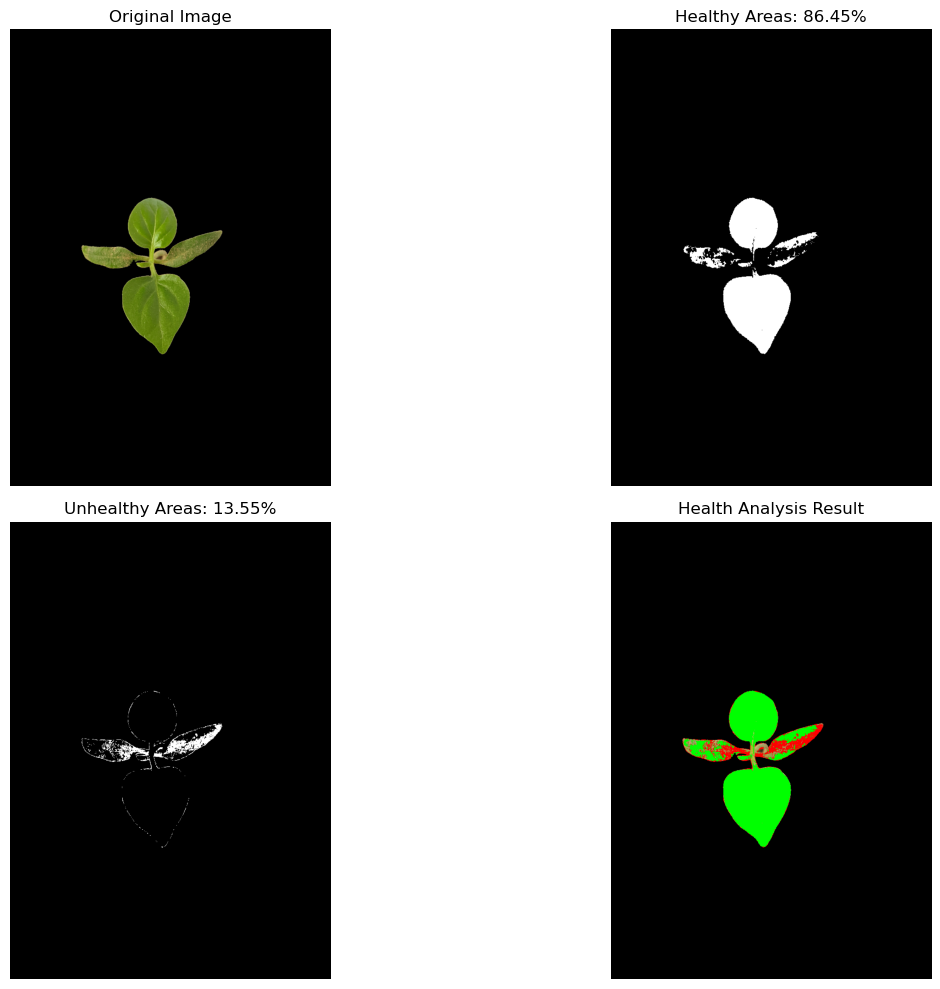

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_health(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Unable to load image.")
        return

    # Resize the image for easier processing
    resized_image = cv2.resize(image, (700, 1000))
    
    # Convert to HSV color space for better color segmentation
    hsv_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2HSV)

    # Define color ranges for healthy (green) and unhealthy (yellow/brown) leaves
    healthy_lower = np.array([35, 40, 40])  # Lower bound for green
    healthy_upper = np.array([85, 255, 255])  # Upper bound for green
    unhealthy_lower = np.array([21, 75, 33])  # Lower bound for yellow/brown
    unhealthy_upper = np.array([34, 255, 147])  # Upper bound for yellow/brown

    # Create masks for healthy and unhealthy regions
    healthy_mask = cv2.inRange(hsv_image, healthy_lower, healthy_upper)
    unhealthy_mask = cv2.inRange(hsv_image, unhealthy_lower, unhealthy_upper)

    # Calculate pixel count for each region
    healthy_pixels = np.count_nonzero(healthy_mask)
    unhealthy_pixels = np.count_nonzero(unhealthy_mask)
    total_relevant_pixels = healthy_pixels + unhealthy_pixels

    if total_relevant_pixels == 0:
        print("No plant regions detected based on color ranges.")
        return

    healthy_percentage = (healthy_pixels / total_relevant_pixels) * 100
    unhealthy_percentage = (unhealthy_pixels / total_relevant_pixels) * 100
    
    # Print health status
    print(f"Healthy Area: {healthy_percentage:.2f}%")
    print(f"Unhealthy Area: {unhealthy_percentage:.2f}%")
    
    if healthy_percentage >= 60:
        print("Plant Health Status: ✅ Healthy")
    else:
        print("Plant Health Status: ❌ Unhealthy")

    # Highlight the regions in the original image
    result_image = resized_image.copy()
    result_image[healthy_mask > 0] = [0, 255, 0]    # Highlight healthy areas in green
    result_image[unhealthy_mask > 0] = [0, 0, 255]  # Highlight unhealthy areas in red

    # Convert BGR to RGB for Matplotlib
    resized_image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)
    result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

    # Create Matplotlib figure
    plt.figure(figsize=(15, 10))

    # Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(resized_image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # Healthy Areas
    plt.subplot(2, 2, 2)
    plt.imshow(healthy_mask, cmap='gray')
    plt.title(f'Healthy Areas: {healthy_percentage:.2f}%')
    plt.axis('off')

    # Unhealthy Areas
    plt.subplot(2, 2, 3)
    plt.imshow(unhealthy_mask, cmap='gray')
    plt.title(f'Unhealthy Areas: {unhealthy_percentage:.2f}%')
    plt.axis('off')

    # Combined Result
    plt.subplot(2, 2, 4)
    plt.imshow(result_image_rgb)
    plt.title('Health Analysis Result')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# function calling
detect_health('largest_green_masked_image.jpg')
